In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# disc labels
#latent_disc ='/work/dlclarge2/aliy-maskgit/concept_graphs/output/single-body_2d_3classes/latent_None/H32-train1/06-03-16-37_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json'

# cont labels
latent_cont_old = '/work/dlclarge2/aliy-maskgit/concept_graphs/results/output/single-body_2d_3classes/latent_None/H32-train1/20-03-10-32_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json'

# cont labels old
latent_cont = '/work/dlclarge2/aliy-maskgit/concept_graphs/results/output/single-body_2d_3classes/H32-train1/25-03-06-58_5000_1.6_256_500_1000_0.0001_None_1500_2.0_1/steps_acc.json'

latent_cont = '/work/dlclarge2/aliy-maskgit/concept_graphs/results/output/single-body_2d_3classes/latent_None/H32-train1/20-03-10-32_5000_1.6_256_500_6000_0.0001_None_1500_2.0_1/steps_acc.json'

In [15]:
line_styles = {
    "000": ("#22a6ff", "solid"),
    "001": ("#22a6ff", "dashed"),
    "010": ("#22a6ff", "dashdot"),
    "100": ("#22a6ff", "dotted"),
    "011": ("#ff95ca", "solid"),
    "101": ("#ff95ca", "dashed"),
    "110": ("#ff95ca", "dashdot"),
    "111": ("#ff00ae", "solid"),
}


In [16]:
def get_dict(path):
    
    with open(path, "r") as f:
        log_data = json.load(f)

    data_by_concept = {}

    for entry in log_data:
        step = entry["step"]
        concept_code = entry["concept_code"]
        accuracy = entry["accuracy"] * 100

        if concept_code not in data_by_concept:
            data_by_concept[concept_code] = {"steps": [], "accuracies": []}

        data_by_concept[concept_code]["steps"].append(step)
        data_by_concept[concept_code]["accuracies"].append(accuracy)
    sorted_keys = sorted(data_by_concept.keys())
    for concept_code in sorted_keys:
        steps = np.array(data_by_concept[concept_code]["steps"])
        accuracies = np.array(data_by_concept[concept_code]["accuracies"])

        sorted_indices = np.argsort(steps)
        data_by_concept[concept_code]["steps"] = steps[sorted_indices]
        data_by_concept[concept_code]["accuracies"] = accuracies[sorted_indices]
    return data_by_concept


In [17]:
#disc_data = get_dict(latent_disc)
cont_data = get_dict(latent_cont)
cont_data_old = get_dict(latent_cont_old)

In [18]:
cont_data

{'100': {'steps': array([  99,  199,  299,  399,  499,  599,  699,  799,  899,  999, 1099,
         1199, 1299, 1399, 1499, 1599, 1699, 1799, 1899, 1999, 2099, 2199,
         2299, 2399, 2499]),
  'accuracies': array([ 20.75195312,  98.4375    , 100.        , 100.        ,
         100.        , 100.        , 100.        , 100.        ,
         100.        , 100.        , 100.        , 100.        ,
         100.        ,  98.4375    , 100.        , 100.        ,
         100.        , 100.        , 100.        , 100.        ,
         100.        , 100.        , 100.        , 100.        ,
         100.        ])},
 '110': {'steps': array([  99,  199,  299,  399,  499,  599,  699,  799,  899,  999, 1099,
         1199, 1299, 1399, 1499, 1599, 1699, 1799, 1899, 1999, 2099, 2199,
         2299, 2399, 2499]),
  'accuracies': array([12.22763062, 67.1875    , 18.75      ,  4.6875    ,  6.25      ,
          7.8125    ,  0.        ,  3.125     ,  4.6875    ,  1.5625    ,
          0.      

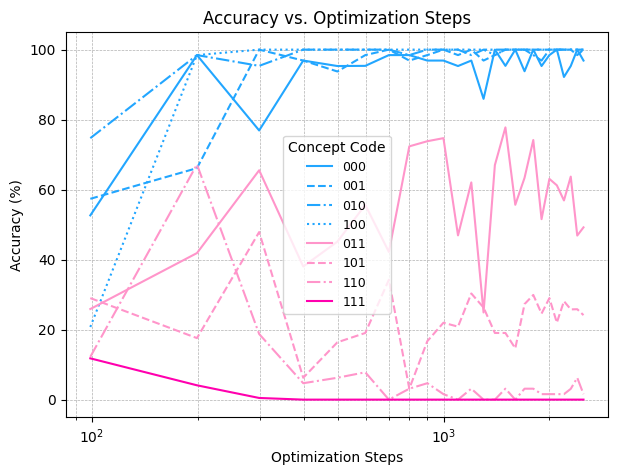

In [19]:
plt.figure(figsize=(7, 5))

for concept_code in line_styles.keys():
    steps = np.array(cont_data[concept_code]["steps"])
    accuracies = np.array(cont_data[concept_code]["accuracies"])

    color, linestyle = line_styles.get(concept_code, ("gray", "solid"))
    plt.plot(steps, accuracies, linestyle=linestyle, color=color, label=concept_code)

plt.xscale("log")
plt.xlabel("Optimization Steps")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs. Optimization Steps")

plt.legend(title="Concept Code", fontsize=9)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()
